In [2]:
# Students Performance Indicator 

# Lifecycle 1) understanding problem statement
#           2) Data Collection
#           3) Data Checks to perform
#           4) Exploritory Data Analysis (EDA)
#           5) Data Pre-processing
#           6) Model Training
#           7) Chosing best Model


In [3]:
# Problem statement

# This project understands how the students scores (test_scores) are affected by other variables
# such as gender , ethinicity , parental level of education , lunch and test preparation

In [4]:
# 1) Data Collection 

In [5]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')

In [6]:
# import data

df = pd.read_csv('data/StudentsPerformance.csv')

In [7]:
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [8]:
# missinf values
df.isna().sum()

gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score                  0
dtype: int64

In [9]:
# duplicates
df.duplicated().sum()

np.int64(0)

In [10]:
# checking datatypes
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race/ethnicity               1000 non-null   object
 2   parental level of education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test preparation course      1000 non-null   object
 5   math score                   1000 non-null   int64 
 6   reading score                1000 non-null   int64 
 7   writing score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB


In [11]:
# checking the number of unique values of each column

df.nunique()

gender                          2
race/ethnicity                  5
parental level of education     6
lunch                           2
test preparation course         2
math score                     81
reading score                  72
writing score                  77
dtype: int64

In [12]:
# Check statistic of dataset
df.describe()

,math score,reading score,writing score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


In [13]:
# 2.1  Exploritory Data

print("Categories in 'gender' variables:             ", end = " ")
print(df["gender"].unique())

print("Categories in 'race/ethnicity variables':     ", end = " ")
print(df["race/ethnicity"].unique())

print("Categories in 'parental level of education' variables:    ", end = " ")
print(df["parental level of education"].unique())

print("Categories in 'luch' variables:    ", end = " ")
print(df["lunch"].unique())

print("Categories in 'test preperation cources' variables:    ", end = " ")
print(df["test preparation course"].unique())

Categories in 'gender' variables:              ['female' 'male']
Categories in 'race/ethnicity variables':      ['group B' 'group C' 'group A' 'group D' 'group E']
Categories in 'parental level of education' variables:     ["bachelor's degree" 'some college' "master's degree" "associate's degree"
 'high school' 'some high school']
Categories in 'luch' variables:     ['standard' 'free/reduced']
Categories in 'test preperation cources' variables:     ['none' 'completed']


In [14]:
# 2.1define numerical & categorial columns\
numerical_features = [feature for feature in df.columns if df[feature].dtype != 'O']
categorical_features = [feature for feature in df.columns if df[feature].dtype =='O']

print("We have {} numerical features: {}".format(len(numerical_features),numerical_features))
print("We have {} categorical_features: {}".format(len(categorical_features), categorical_features))

We have 3 numerical features: ['math score', 'reading score', 'writing score']
We have 5 categorical_features: ['gender', 'race/ethnicity', 'parental level of education', 'lunch', 'test preparation course']


In [15]:
# 2.3 Adding columns for "Total Score" and "Average"

df["total_score"] = df["math score"] + df["writing score"]
df["average"] = df["total_score"]/3

df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score,total_score,average
0,female,group B,bachelor's degree,standard,none,72,72,74,146,48.666667
1,female,group C,some college,standard,completed,69,90,88,157,52.333333
2,female,group B,master's degree,standard,none,90,95,93,183,61.000000
3,male,group A,associate's degree,free/reduced,none,47,57,44,91,30.333333
4,male,group C,some college,standard,none,76,78,75,151,50.333333


In [16]:
reading_full = df[df["reading score"]  == 100]["average"].count()
writing_full = df[df["writing score"]  == 100]["average"].count()
math_full = df[df["math score"]  == 100]["average"].count()

print(f"Number of students with full marks in maths     : {math_full}")
print(f"Number of students with full marks in reading   :{reading_full}")
print(f"Number of students with full marks in writing   :{writing_full}")

Number of students with full marks in maths     : 7
Number of students with full marks in reading   :17
Number of students with full marks in writing   :14


In [17]:
reading_full = df[df["reading score"]  <=20 ]["average"].count()
writing_full = df[df["writing score"]  <=20]["average"].count()
math_full = df[df["math score"]  <=20]["average"].count()

print(f"Number of students with less than 20 marks in maths       : {math_full}")
print(f"Number of students with less than 20 marks in reading     : {reading_full}")
print(f"Number of students with less than 20 marks in writing     : {writing_full}")

Number of students with less than 20 marks in maths       : 4
Number of students with less than 20 marks in reading     : 1
Number of students with less than 20 marks in writing     : 3


In [18]:
# EDA (visual data)


# Histogram 
# Kernal Dsitribution Functino (KDE)

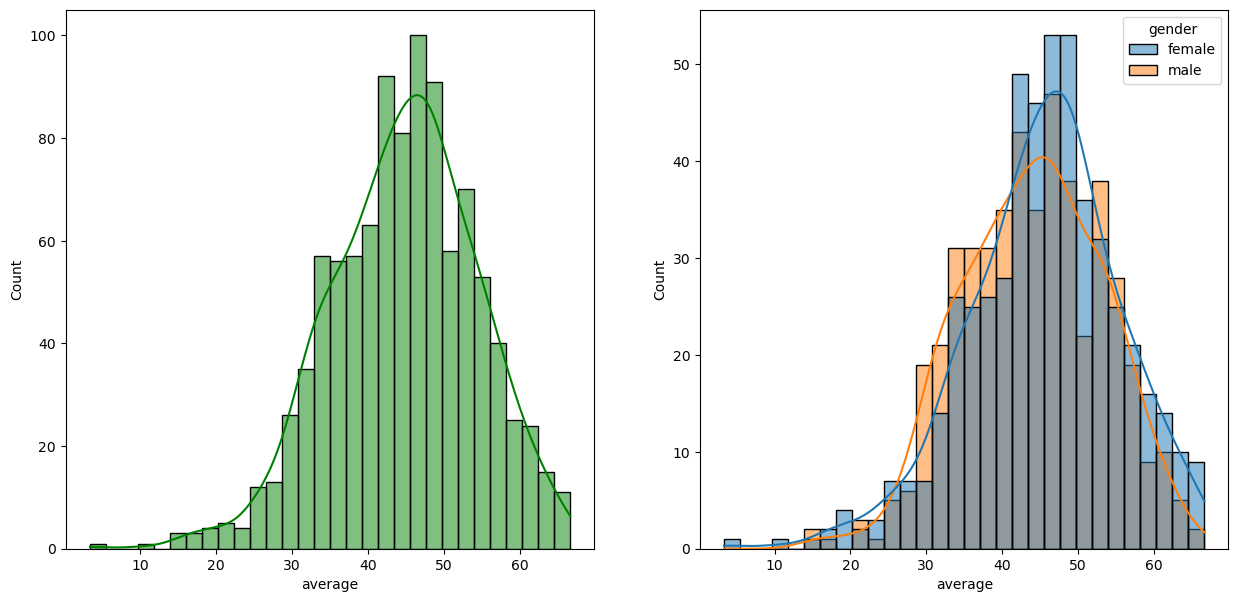

In [19]:
fig, axs = plt.subplots(1,2,figsize = (15,7))
plt.subplot(121)

sns.histplot(data = df, x= 'average',bins =30, kde =True, color = 'g')
plt.subplot(122)

sns.histplot(data = df, x= 'average', bins =30, kde =True, hue ='gender')
plt.show()


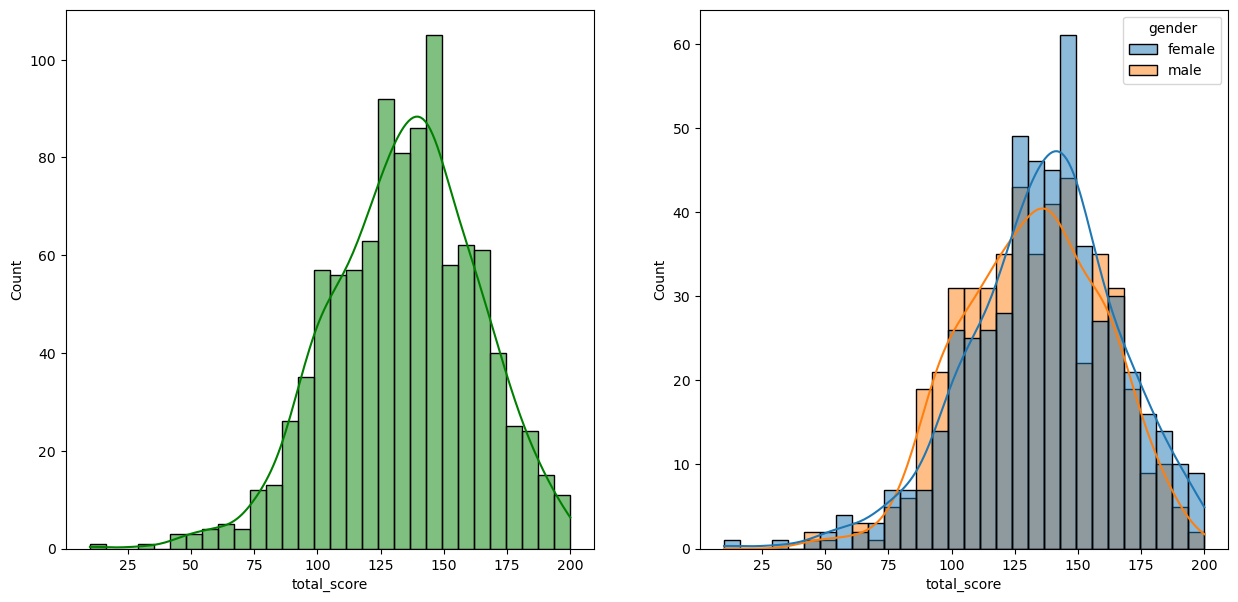

In [20]:
fig, axs = plt.subplots(1,2,figsize = (15,7))
plt.subplot(121)

sns.histplot(data = df, x= 'total_score',bins =30, kde =True, color = 'g')
plt.subplot(122)

sns.histplot(data = df, x= 'total_score', bins =30, kde =True, hue ='gender')
plt.show()

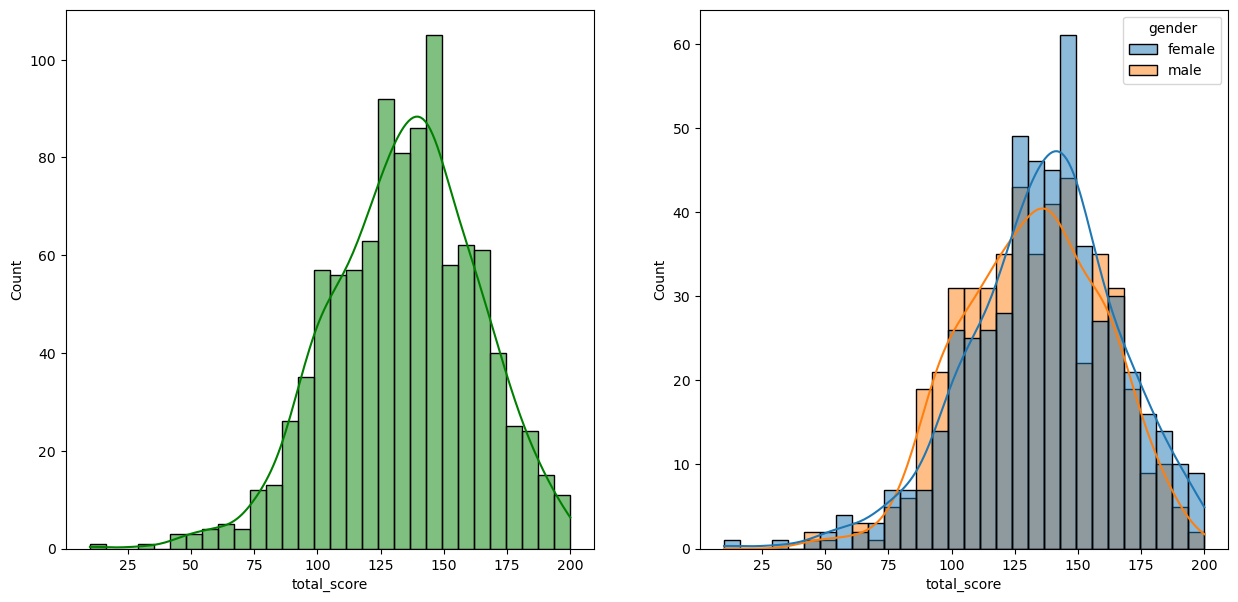

In [21]:
fig, axs = plt.subplots(1,2,figsize = (15,7))
plt.subplot(121)

sns.histplot(data = df, x= 'total_score',bins =30, kde =True, color = 'g')
plt.subplot(122)

sns.histplot(data = df, x= 'total_score', bins =30, kde =True, hue ='gender')
plt.show()

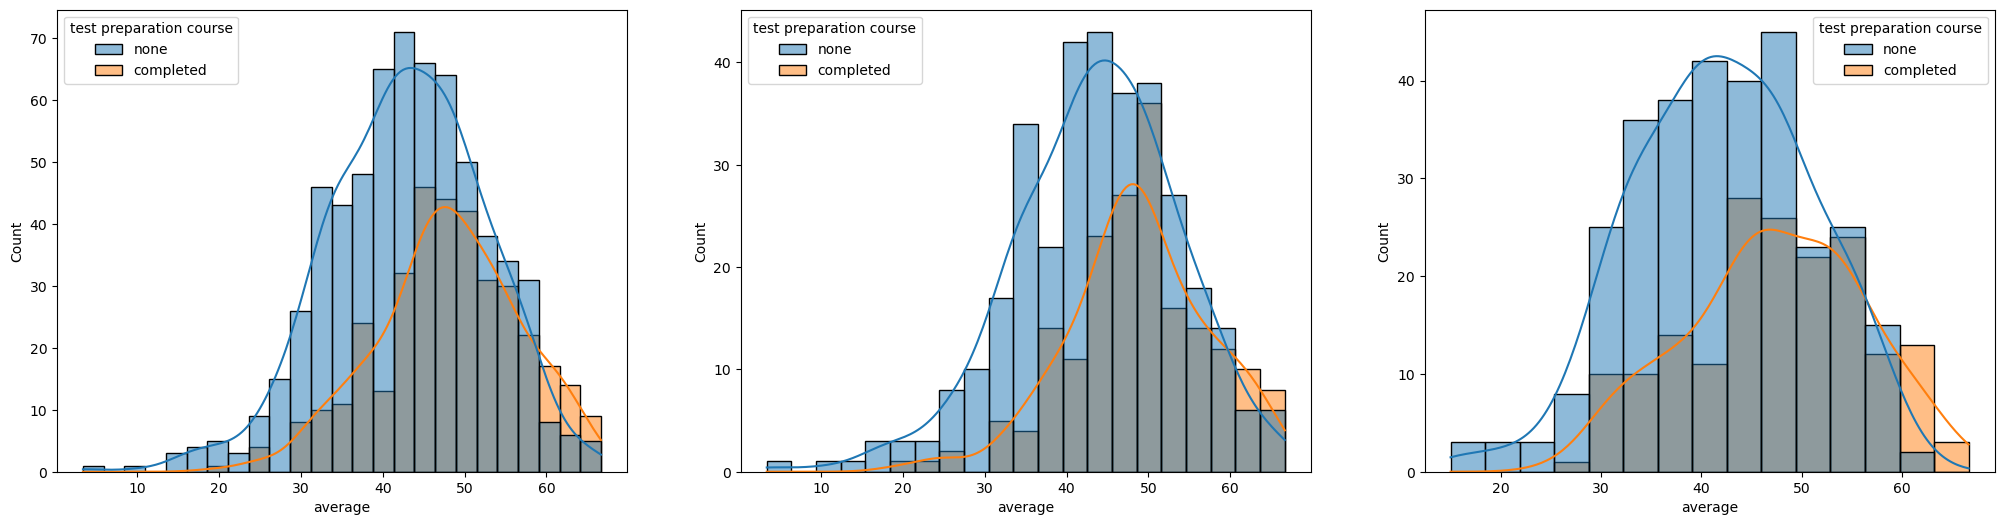

In [22]:
# 1. Set the overall figure size first
plt.figure(figsize=(25, 6))

# 2. Use plt.subplot(rows, columns, index)
# Subplot 1
plt.subplot(1, 3, 1)
sns.histplot(data=df, x='average', kde=True, hue='test preparation course')

# Subplot 2
plt.subplot(1, 3, 2)
sns.histplot(data=df[df.gender == 'female'], x='average', kde=True, hue='test preparation course')

# Subplot 3
plt.subplot(1, 3, 3)
sns.histplot(data=df[df.gender == 'male'], x='average', kde=True, hue='test preparation course')

plt.show()

In [23]:
# insight -> standard luche helps well in exam

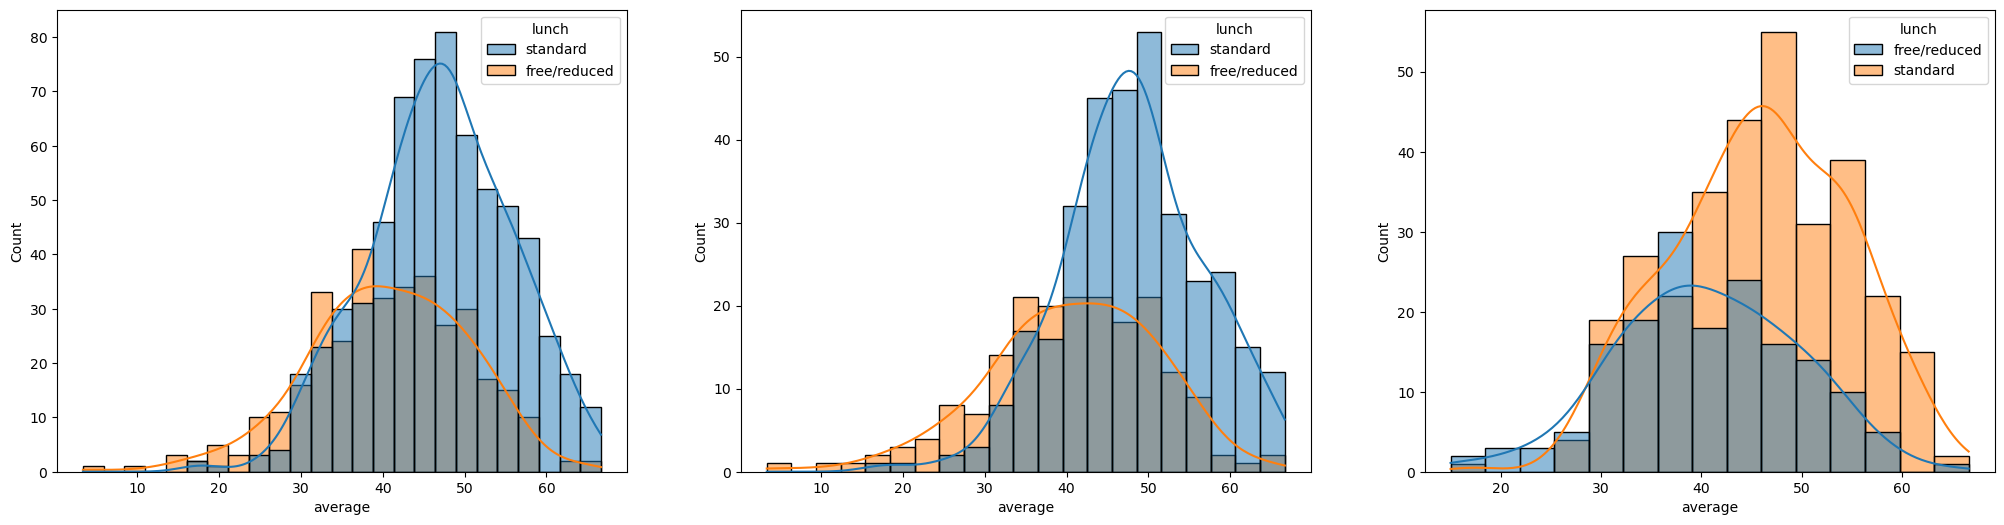

In [24]:
plt.figure(figsize=(25, 6))

# 2. Use plt.subplot(rows, columns, index)
# Subplot 1
plt.subplot(1, 3, 1)
sns.histplot(data=df, x='average', kde=True, hue='lunch')

# Subplot 2
plt.subplot(1, 3, 2)
sns.histplot(data=df[df.gender == 'female'], x='average', kde=True, hue='lunch')

# Subplot 3
plt.subplot(1, 3, 3)
sns.histplot(data=df[df.gender == 'male'], x='average', kde=True, hue='lunch')

plt.show()

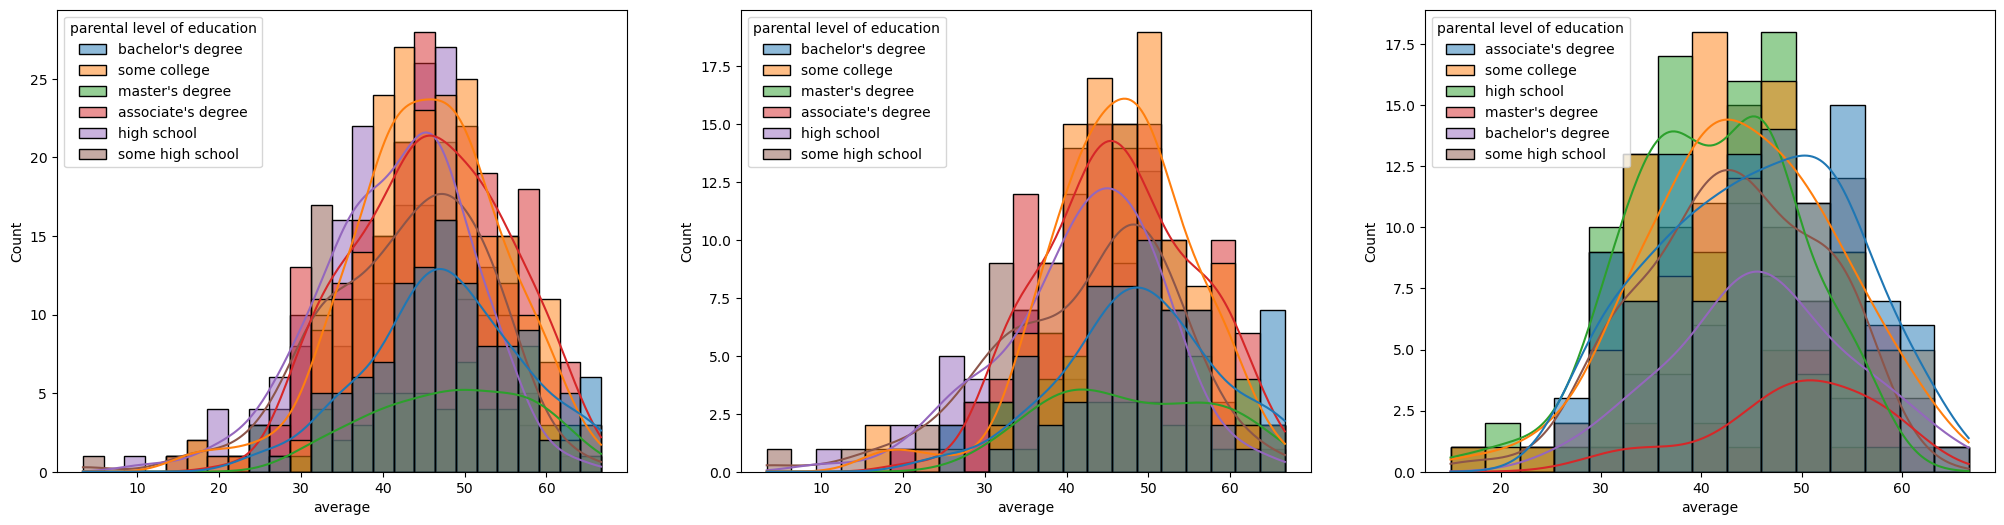

In [25]:
plt.figure(figsize=(25, 6))

# 2. Use plt.subplot(rows, columns, index)
# Subplot 1
plt.subplot(1, 3, 1)
sns.histplot(data=df, x='average', kde=True, hue='parental level of education')

# Subplot 2
plt.subplot(1, 3, 2)
sns.histplot(data=df[df.gender == 'female'], x='average', kde=True, hue='parental level of education')

# Subplot 3
plt.subplot(1, 3, 3)
sns.histplot(data=df[df.gender == 'male'], x='average', kde=True, hue='parental level of education')

plt.show()

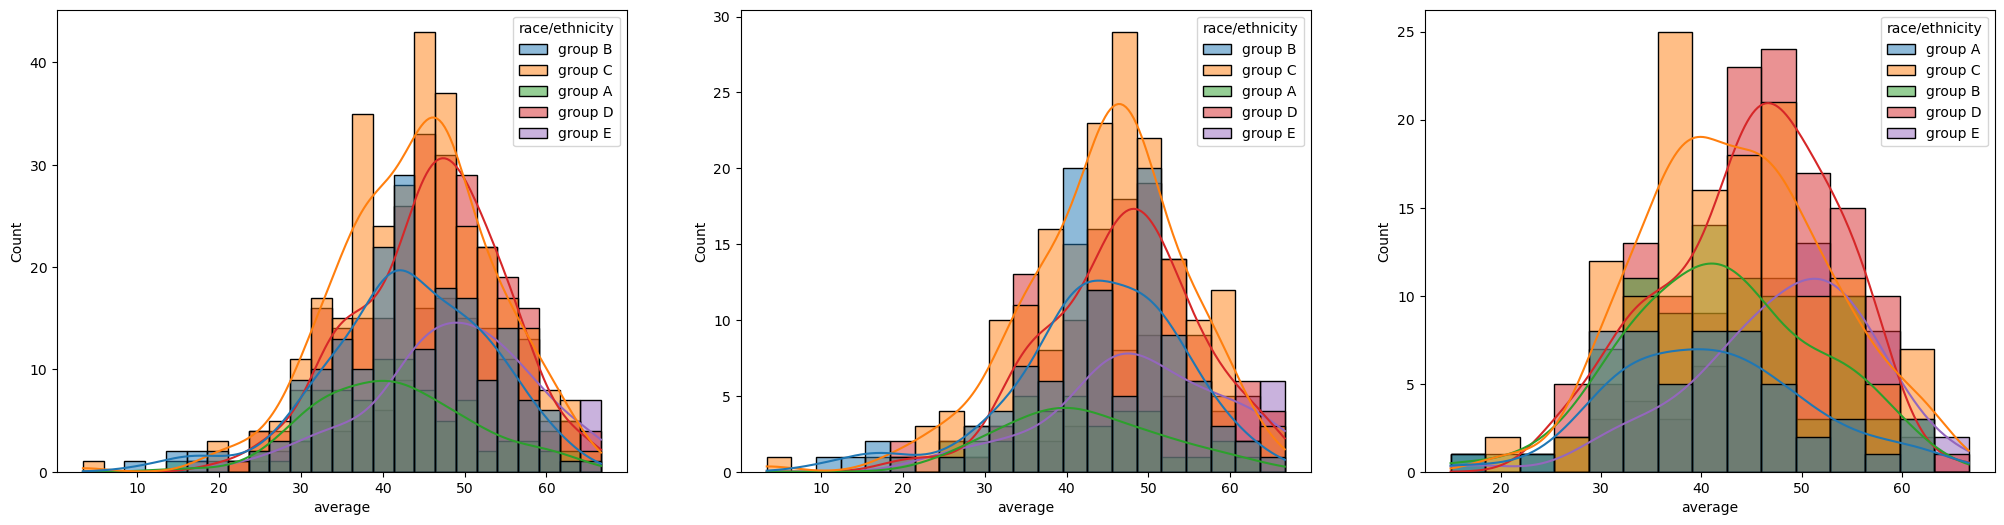

In [26]:
plt.figure(figsize=(25, 6))

# 2. Use plt.subplot(rows, columns, index)
# Subplot 1
plt.subplot(1, 3, 1)
sns.histplot(data=df, x='average', kde=True, hue='race/ethnicity')

# Subplot 2
plt.subplot(1, 3, 2)
sns.histplot(data=df[df.gender == 'female'], x='average', kde=True, hue='race/ethnicity')

# Subplot 3
plt.subplot(1, 3, 3)
sns.histplot(data=df[df.gender == 'male'], x='average', kde=True, hue='race/ethnicity')

plt.show()


In [27]:
# insght -> group A and B tends to perform poorly in exams
#        -> group A and B tends to perform poorly i nexms irresptive of the their gender

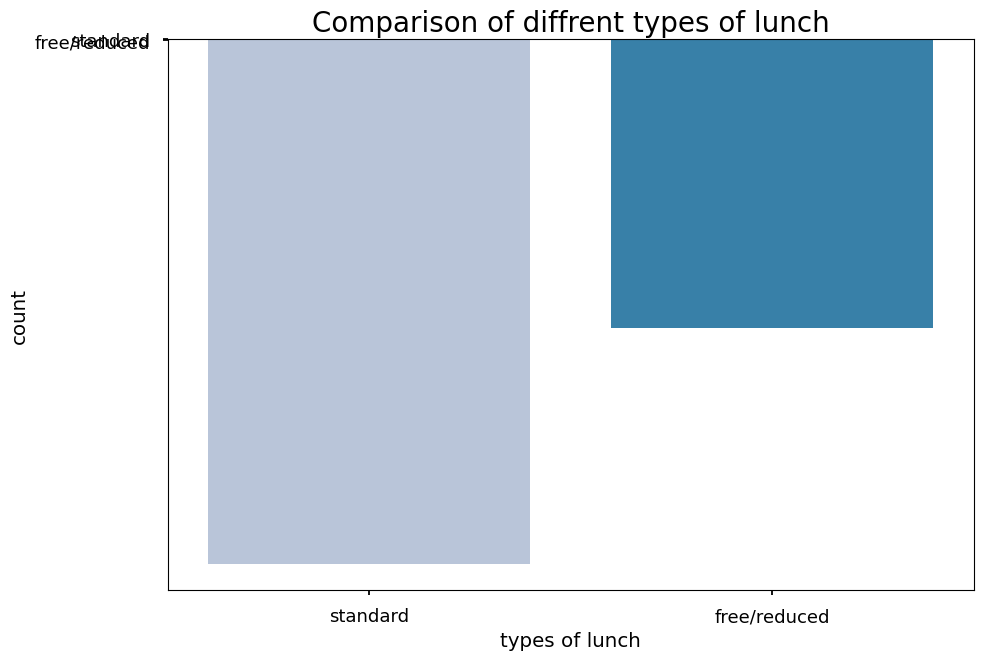

In [32]:
# univariable analysis  (which type of lunch is most common among the students)
import seaborn as sns
import matplotlib.pyplot as plt

plt.rcParams['figure.figsize'] = (15,9)
plt.style.use('seaborn-v0_8-talk')
sns.countplot(x=df['lunch'], palette='PuBu') # Note: corrected 'palatte' typo to 'palette'
plt.title('Comparison of diffrent types of lunch', fontweight =30 , fontsize = 20)
plt.xlabel('types of lunch')
plt.ylabel('count')
plt.show()

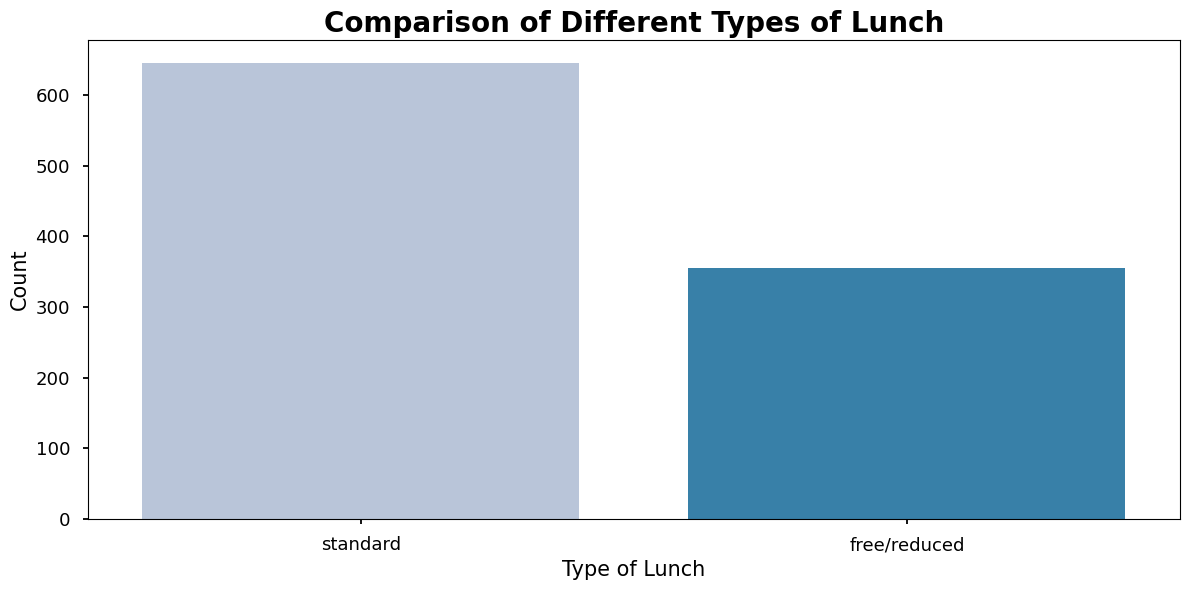

In [33]:
import seaborn as sns
import matplotlib.pyplot as plt

# Set the style and figure size
plt.style.use('seaborn-v0_8-talk')
plt.figure(figsize=(12, 6)) # Slightly smaller width often helps alignment

# Plot using the data parameter to avoid alignment glitches
sns.countplot(x='lunch', data=df, palette='PuBu')

# Add titles and labels
plt.title('Comparison of Different Types of Lunch', fontweight='bold', fontsize=20)
plt.xlabel('Type of Lunch', fontsize=15)
plt.ylabel('Count', fontsize=15)

# This command fixes the overlapping and "off-center" feel
plt.tight_layout()

plt.show()